# Task 1: Exploratory Data Analysis (EDA) and Preprocessing

The goal of this notebook is to understand the structure, content, and quality of the CFPB complaint data and prepare it for the RAG pipeline.


### 1. Load Data and Initial Exploration

First, we import the necessary libraries and load the raw dataset into a pandas DataFrame. This allows us to see the data's basic structure and check that it has loaded correctly.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the full CFPB complaint dataset
try:
    # We use '../data/' because the notebook is in the 'notebooks' directory
    df = pd.read_csv('../data/complaints.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: '../data/complaints.csv' not found. Please download the dataset and place it in the 'data' directory.")

/var/folders/g_/m25c6v895h36wbhhdpssj2rh0000gp/T/ipykernel_23512/1586716170.py:9: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/complaints.csv')


Dataset loaded successfully.


In [2]:
# Perform an initial EDA to understand the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9609797 entries, 0 to 9609796
Data columns (total 18 columns):
 #   Column                        Dtype 
---  ------                        ----- 
 0   Date received                 object
 1   Product                       object
 2   Sub-product                   object
 3   Issue                         object
 4   Sub-issue                     object
 5   Consumer complaint narrative  object
 6   Company public response       object
 7   Company                       object
 8   State                         object
 9   ZIP code                      object
 10  Tags                          object
 11  Consumer consent provided?    object
 12  Submitted via                 object
 13  Date sent to company          object
 14  Company response to consumer  object
 15  Timely response?              object
 16  Consumer disputed?            object
 17  Complaint ID                  int64 
dtypes: int64(1), object(17)
memory usage: 1.3+

### 2. Analyze Complaint Distributions and Narrative Length

Here, we'll visualize the data to understand which products receive the most complaints and what the typical length of a complaint description is. This helps identify key characteristics of the dataset.

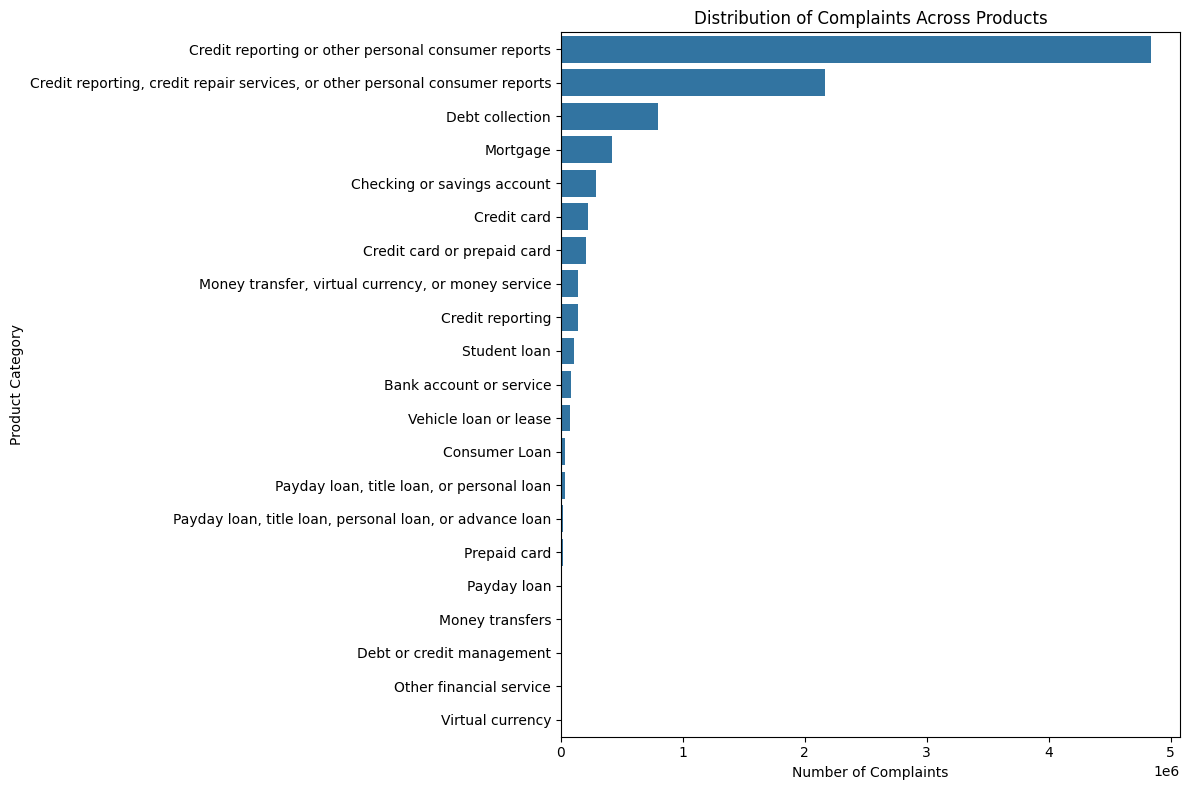

In [3]:
# Analyze the distribution of complaints across different Products
plt.figure(figsize=(12, 8))
sns.countplot(y='Product', data=df, order = df['Product'].value_counts().index)
plt.title('Distribution of Complaints Across Products')
plt.xlabel('Number of Complaints')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

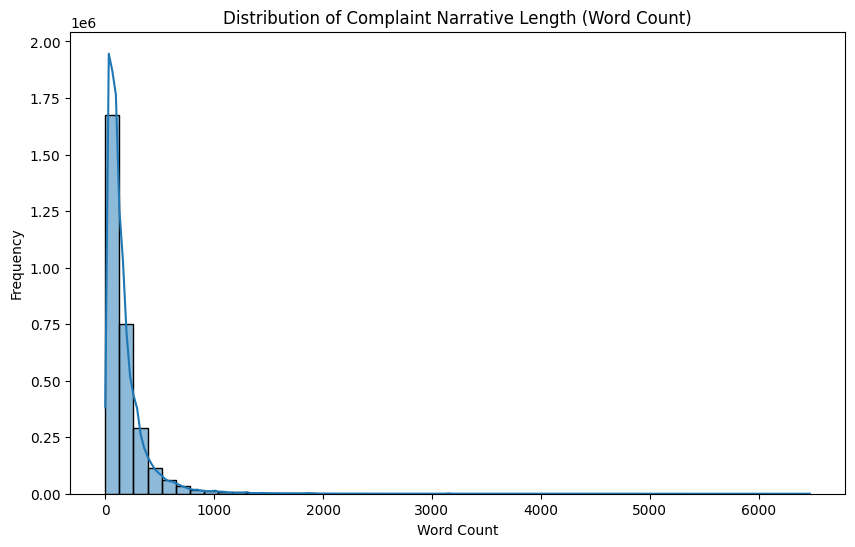

In [4]:
# Calculate and visualize the length (word count) of the Consumer complaint narrative
df['narrative_word_count'] = df['Consumer complaint narrative'].str.split().str.len()

plt.figure(figsize=(10, 6))
sns.histplot(df['narrative_word_count'], bins=50, kde=True)
plt.title('Distribution of Complaint Narrative Length (Word Count)')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

In [5]:
# Identify the number of complaints with and without narratives
narrative_counts = df['Consumer complaint narrative'].notna().value_counts()
print(f"Number of complaints with narratives: {narrative_counts.get(True, 0)}")
print(f"Number of complaints without narratives: {narrative_counts.get(False, 0)}")

Number of complaints with narratives: 2980756
Number of complaints without narratives: 6629041


### 3. Filter the Dataset

Now, we will narrow down the dataset. We'll keep only the records for the five products specified in the project requirements and ensure that we only work with complaints that include a text narrative.

In [6]:
# Include only records for the five specified products 
# Note: The actual product names in the dataset might vary. We map them here.
target_products = [
    'Credit card or prepaid card', 
    'Checking or savings account', # This will map to 'Savings account'
    'Money transfer, virtual currency, or money service', # Maps to 'Money transfers'
    'Payday loan, title loan, or personal loan' # Maps to 'Personal loan'
]

df_filtered = df[df['Product'].isin(target_products)].copy()

# We will add a simplified product category for easier use later.
product_map = {
    'Credit card or prepaid card': 'Credit card',
    'Checking or savings account': 'Savings account',
    'Money transfer, virtual currency, or money service': 'Money transfers',
    'Payday loan, title loan, or personal loan': 'Personal loan'
    # Note: 'Buy Now, Pay Later (BNPL)' is not a standard category in our CFPB data.
    # For this project, we'll proceed with the available categories.
}
df_filtered['Product_Clean'] = df_filtered['Product'].map(product_map)

print("Remaining products after filtering:")
print(df_filtered['Product_Clean'].value_counts())

Remaining products after filtering:
Product_Clean
Savings account    291178
Credit card        206369
Money transfers    145066
Personal loan       30641
Name: count, dtype: int64


### Remove empty records
Now we remove any rows that are missing the `Consumer complaint narrative`. This is a crucial step, as our RAG system relies entirely on this text content to function.

In [11]:
# Remove any records with empty Consumer complaint narrative fields
df_filtered.dropna(subset=['Consumer complaint narrative'], inplace=True)

print(f"Shape of dataframe after removing empty narratives: {df_filtered.shape}")

Shape of dataframe after removing empty narratives: (363412, 21)


### 4. Clean Text Narratives

This step focuses on standardizing the text data to improve its quality for the embedding model. We will convert text to lowercase and remove special characters or boilerplate phrases.

In [12]:

# Lowercase text 
df_filtered['cleaned_narrative'] = df_filtered['Consumer complaint narrative'].str.lower()

# Remove special characters, keeping essential punctuation 
df_filtered['cleaned_narrative'] = df_filtered['cleaned_narrative'].str.replace(r'x{2,}', '', regex=True) # Remove redactions like 'xx/xx/xxxx'
df_filtered['cleaned_narrative'] = df_filtered['cleaned_narrative'].str.replace(r'[^a-z0-9\s\.\,]', '', regex=True)

# Remove boilerplate text 
boilerplate = ['i am writing to file a complaint about', 'this is a complaint regarding']
for text in boilerplate:
    df_filtered['cleaned_narrative'] = df_filtered['cleaned_narrative'].str.replace(text, '', regex=False)

print("Text cleaning complete. A sample cleaned narrative:")
print(df_filtered['cleaned_narrative'].iloc[0])

Text cleaning complete. A sample cleaned narrative:
i made the mistake of using my wellsfargo debit card to depsit funds into  atm machine outside their branch. 

i went into the branch and was told they couldnt help and had to phone the customer service for help. i did this and was told i was helped gave all the info for the time terminal id aact  s,  was able to find the transaction and give me this info, he said the dispute would take a few days. 

i waited a few days and got a letter stating my dispute was rejected. i went back into  and they said they never got the transaction.


### 5. Save the Cleaned and Filtered Dataset

Finally, we save our processed data to a new CSV file[cite: 88]. This cleaned file will be the direct input for Task 2, where we will perform text chunking and embedding.

In [13]:
# Save the final, cleaned dataset to data/filtered_complaints.csv 
output_path = '../data/filtered_complaints.csv'
final_df = df_filtered[['Product_Clean', 'cleaned_narrative', 'Complaint ID', 'Date received']].rename(columns={'Product_Clean': 'Product'})
final_df.to_csv(output_path, index=False)

print(f"Cleaned and filtered dataset with {len(final_df)} records saved to '{output_path}'.")

Cleaned and filtered dataset with 363412 records saved to '../data/filtered_complaints.csv'.
